Topic: Handling Imbalanced Data
Author: Pooja Goswami
Repository: Machine Learning Journey

Techniques Covered:
1. Random Over Sampling
2. Random Under Sampling
3. SMOTE
4. Class Distribution Comparison
"""

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../datasets/05_imbalanced_data.csv")

print("Original Dataset:")
print(df)

Original Dataset:
    id  age  salary  purchased
0    1   22   25000          0
1    2   25   30000          0
2    3   28   35000          0
3    4   30   40000          0
4    5   32   45000          0
5    6   35   50000          0
6    7   38   55000          0
7    8   40   60000          0
8    9   42   65000          0
9   10   45   70000          0
10  11   23   28000          0
11  12   27   33000          0
12  13   31   42000          0
13  14   36   52000          0
14  15   41   62000          0
15  16   26   31000          0
16  17   34   48000          0
17  18   39   58000          0
18  19   44   68000          0
19  20   29   37000          0
20  21   33   46000          1
21  22   37   54000          1


In [3]:
print("Original Class Distribution:")
print(df["purchased"].value_counts())

Original Class Distribution:
purchased
0    20
1     2
Name: count, dtype: int64


In [4]:
# -------------------------------
# Random Over Sampling
# -------------------------------

majority_class = df[df["purchased"] == 0]
minority_class = df[df["purchased"] == 1]

minority_oversampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

oversampled_df = pd.concat(
    [majority_class, minority_oversampled]
)

print("Class Distribution After Random Over Sampling:")
print(oversampled_df["purchased"].value_counts())

Class Distribution After Random Over Sampling:
purchased
0    20
1    20
Name: count, dtype: int64


In [5]:
# -------------------------------
# Random Under Sampling
# -------------------------------

majority_undersampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

undersampled_df = pd.concat(
    [majority_undersampled, minority_class]
)

print("Class Distribution After Random Under Sampling:")
print(undersampled_df["purchased"].value_counts())

Class Distribution After Random Under Sampling:
purchased
0    2
1    2
Name: count, dtype: int64


In [6]:
# -------------------------------
# SMOTE
# -------------------------------

X = df.drop("purchased", axis=1)
y = df["purchased"]

smote = SMOTE(k_neighbors=1, random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

print("Class Distribution After SMOTE:")
print(y_smote.value_counts())

Class Distribution After SMOTE:
purchased
0    20
1    20
Name: count, dtype: int64


In [7]:
# -------------------------------
# Class Distribution Comparison
# -------------------------------

original_counts = df["purchased"].value_counts().sort_index()
oversampled_counts = oversampled_df["purchased"].value_counts().sort_index()
undersampled_counts = undersampled_df["purchased"].value_counts().sort_index()
smote_counts = y_smote.value_counts().sort_index()

comparison = pd.DataFrame({
    "Original": original_counts,
    "Over Sampling": oversampled_counts,
    "Under Sampling": undersampled_counts,
    "SMOTE": smote_counts
})

print("Class Distribution Comparison:")
print(comparison)

Class Distribution Comparison:
           Original  Over Sampling  Under Sampling  SMOTE
purchased                                                
0                20             20               2     20
1                 2             20               2     20


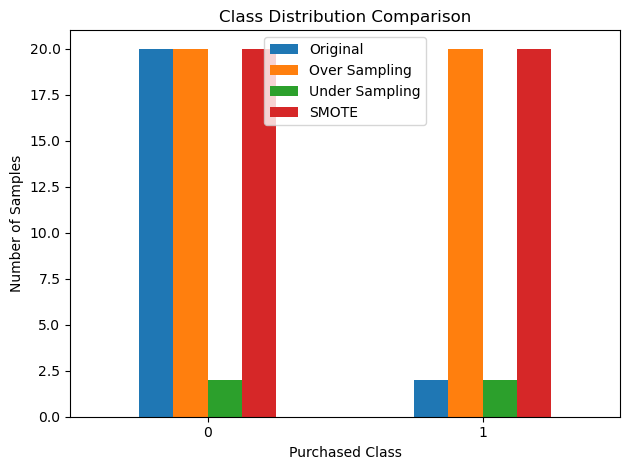

In [8]:
# Class Distribution Comparison Plot

comparison.plot(kind="bar")

plt.title("Class Distribution Comparison")
plt.xlabel("Purchased Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.show()

## Conclusion

Imbalanced data occurs when one class has significantly more samples than another.

In this notebook, we learned three techniques to handle imbalanced data:

- **Random Over Sampling:** Increases minority class samples by duplicating existing samples.
- **Random Under Sampling:** Reduces majority class samples.
- **SMOTE:** Creates synthetic samples for the minority class.

For this dataset:

- Original distribution: 20 majority and 2 minority samples.
- Random Over Sampling: 20 and 20.
- Random Under Sampling: 2 and 2.
- SMOTE: 20 and 20.

SMOTE is generally preferred over simple duplication when enough minority samples are available because it creates synthetic samples instead of simply copying existing ones.